# GTSRB — Baseline vs Virtual Adversarial Training
Dataset: German Traffic Sign Recognition Benchmark (Kaggle)  
Architectures: **FCN** (fully connected) and **SmallCNN** (VGG-style)  
Modes: **baseline** (supervised cross-entropy) and **vat** (+ VAT regularisation)  

Change `Config` fields in the experiment cells — all training logic is shared.

In [1]:
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

from dataclasses import dataclass
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | scikit-learn imported | device: {DEVICE}')

PyTorch 2.11.0+cu128 | scikit-learn imported | device: cuda


## Config

In [2]:
@dataclass
class Config:
    # ── Dataset ────────────────────────────────────────────────────────
    dataset_type: str       = 'moons'   # 'moons' | 'circles'
    n_samples: int          = 2000      # total points generated
    noise: float            = 0.15      # label-boundary noise
    labeled_fraction: float = 0.10      # fraction of train set that is labelled

    # ── Input / output ─────────────────────────────────────────────────
    in_features: int        = 2         # 2-D sklearn datasets
    num_classes: int        = 2

    # ── Model ──────────────────────────────────────────────────────────
    model_type: str         = 'FCN'     # 'FCN' | 'SmallCNN'
    dropout: float          = 0.3

    # ── Training ───────────────────────────────────────────────────────
    mode: str               = 'baseline'  # 'baseline' | 'vat'
    batch_size: int         = 64
    epochs: int             = 10
    lr: float               = 1e-3
    weight_decay: float     = 1e-4
    val_fraction: float     = 0.15
    patience: int           = 15

    # ── VAT ────────────────────────────────────────────────────────────
    vat_eps: float          = 0.5
    vat_xi: float           = 1e-6
    vat_num_iters: int      = 1
    vat_alpha: float        = 1.0

    # ── Misc ───────────────────────────────────────────────────────────
    seed: int               = 42

print(Config())

Config(dataset_type='moons', n_samples=2000, noise=0.15, labeled_fraction=0.1, in_features=2, num_classes=2, model_type='FCN', dropout=0.3, mode='baseline', batch_size=64, epochs=10, lr=0.001, weight_decay=0.0001, val_fraction=0.15, patience=15, vat_eps=0.5, vat_xi=1e-06, vat_num_iters=1, vat_alpha=1.0, seed=42)


## Model Architectures

In [3]:
class FCN(nn.Module):
    """
    Shallow fully-connected network for 2-D inputs.
    Architecture: 2 → 128 → 128 → num_classes  (BN + ReLU + Dropout).
    Analogue of the original FCN used in the VAT paper.
    """
    def __init__(self, in_features: int, num_classes: int, dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 128),         nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class SmallCNN(nn.Module):
    """
    Small 1-D CNN adapted for 2-D tabular inputs (moons / circles).

    The 2 raw features have no spatial structure, so they are first projected
    to a 16-D embedding and treated as a 1-D sequence (length=16, channels=1).
    Two Conv1d blocks then mirror the original VGG-style structure:
        Block 1: Conv → Conv → MaxPool  (length 16 → 8)
        Block 2: Conv → Conv → MaxPool  (length  8 → 4)
    FC head: 64×4 = 256 → 128 → num_classes
    """
    def __init__(self, in_features: int = 2, num_classes: int = 2, dropout: float = 0.3):
        super().__init__()
        self.embed = nn.Linear(in_features, 16)   # (B,2) → (B,16)

        self.features = nn.Sequential(
            # Block 1: length 16 → 8
            nn.Conv1d(1,  32, kernel_size=3, padding=1), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 32, kernel_size=3, padding=1), nn.BatchNorm1d(32), nn.ReLU(),
            nn.MaxPool1d(2), nn.Dropout(dropout / 2),
            # Block 2: length 8 → 4
            nn.Conv1d(32, 64, kernel_size=3, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(2), nn.Dropout(dropout / 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                                # 64 × 4 = 256
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.embed(x)).unsqueeze(1)   # (B,2) → (B,16) → (B,1,16)
        return self.classifier(self.features(x))


def build_model(cfg: Config) -> nn.Module:
    if cfg.model_type == 'FCN':
        return FCN(cfg.in_features, cfg.num_classes, cfg.dropout)
    elif cfg.model_type == 'SmallCNN':
        return SmallCNN(cfg.in_features, cfg.num_classes, cfg.dropout)
    else:
        raise ValueError(f'Unknown model_type: {cfg.model_type}')


# Smoke test
for mt in ('FCN', 'SmallCNN'):
    cfg_tmp = Config(model_type=mt)
    m   = build_model(cfg_tmp)
    out = m(torch.randn(8, 2))
    p   = sum(x.numel() for x in m.parameters())
    print(f'  {mt:10}  out={tuple(out.shape)}  params={p:,}')

  FCN         out=(8, 2)  params=17,666
  SmallCNN    out=(8, 2)  params=55,634


## Data Loading

In [4]:
SENTINEL = -1   # label value used for unlabelled training samples


class SemiSupervisedDataset(Dataset):
    """
    Simple dataset wrapper for (X, y) tensors.
    y == SENTINEL (-1) marks unlabelled samples.
    Val / test sets contain no SENTINEL labels.
    """
    def __init__(self, X: torch.Tensor, y: torch.Tensor):
        self.X, self.y = X, y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def get_loaders(cfg: Config):
    torch.manual_seed(cfg.seed)
    np.random.seed(cfg.seed)

    # ── 1. Generate 2-D data ─────────────────────────────────────────
    if cfg.dataset_type == 'moons':
        X, y = make_moons(n_samples=cfg.n_samples, noise=cfg.noise,
                          random_state=cfg.seed)
    elif cfg.dataset_type == 'circles':
        X, y = make_circles(n_samples=cfg.n_samples, noise=cfg.noise,
                             factor=0.5, random_state=cfg.seed)
    else:
        raise ValueError(f'Unknown dataset_type: {cfg.dataset_type}')

    # ── 2. 70 / 15 / 15 stratified split ─────────────────────────────
    X_train, X_tmp, y_train, y_tmp = train_test_split(
        X, y, test_size=0.30, random_state=cfg.seed, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_tmp, y_tmp, test_size=0.50, random_state=cfg.seed, stratify=y_tmp
    )

    # ── 3. Mask labels — keep only labeled_fraction as labelled ───────
    rng = np.random.default_rng(cfg.seed)
    n_labelled = int(len(y_train) * cfg.labeled_fraction)   # Fully Supervised
    idx = np.arange(len(y_train))
    rng.shuffle(idx)

    y_semi = np.full_like(y_train, SENTINEL)
    y_semi[idx[:n_labelled]] = y_train[idx[:n_labelled]]

    n_unlabelled = (y_semi == SENTINEL).sum()
    print(f'  {cfg.dataset_type}  '
          f'train={len(y_train)} '
          f'(labelled={n_labelled}, unlabelled={n_unlabelled})  '
          f'val={len(y_val)}  test={len(y_test)}')

    # ── 4. → float32 tensors ──────────────────────────────────────────
    def to_t(arr_x, arr_y):
        return (torch.tensor(arr_x, dtype=torch.float32),
                torch.tensor(arr_y, dtype=torch.long))

    X_tr, y_tr = to_t(X_train, y_semi)
    X_vl, y_vl = to_t(X_val,   y_val)
    X_ts, y_ts = to_t(X_test,  y_test)

    kw = dict(batch_size=cfg.batch_size)
    train_loader = DataLoader(SemiSupervisedDataset(X_tr, y_tr),
                              shuffle=True, drop_last=True, **kw)
    val_loader   = DataLoader(SemiSupervisedDataset(X_vl, y_vl),
                              shuffle=False, **kw)
    test_loader  = DataLoader(SemiSupervisedDataset(X_ts, y_ts),
                              shuffle=False, **kw)

    return train_loader, val_loader, test_loader

## VAT Loss

In [5]:
def _l2_normalize(t: torch.Tensor) -> torch.Tensor:
    """Unit-L2-normalise each sample in the batch."""
    flat = t.view(t.size(0), -1)
    norm = flat.norm(p=2, dim=1, keepdim=True).clamp(min=1e-8)
    return (flat / norm).view_as(t)


def vat_loss(model: nn.Module, x: torch.Tensor,
             eps: float = 1.0, xi: float = 1e-6, num_iters: int = 1) -> torch.Tensor:
    """
    Virtual Adversarial Training regularisation loss.
    Miyato et al., 'Virtual Adversarial Training', TPAMI 2019.

    Returns  KL( p(y|x; theta) || p(y|x+r_adv; theta) )
    where r_adv is the worst-case L2-bounded perturbation found via
    power iteration (num_iters=1 is standard and sufficient in practice).
    """
    # Clean distribution — treated as a fixed target, no gradient
    with torch.no_grad():
        p_clean = F.softmax(model(x), dim=1)

    # Random unit-norm starting direction
    d = _l2_normalize(torch.randn_like(x))

    # Power iteration: find direction that maximises KL divergence
    for _ in range(num_iters):
        d = d.detach().requires_grad_(True)
        kl = F.kl_div(
            F.log_softmax(model(x + xi * d), dim=1),
            p_clean, reduction='batchmean'
        )
        # Gradient only w.r.t. d — model-param gradients are NOT accumulated here
        (grad_d,) = torch.autograd.grad(kl, d)
        d = _l2_normalize(grad_d.detach())

    # Final VAT loss — gradient flows to model params via this forward pass
    x_adv = (x + eps * d).detach()
    return F.kl_div(
        F.log_softmax(model(x_adv), dim=1),
        p_clean.detach(), reduction='batchmean'
    )

## Trainer
A single `train()` function handles both modes — switch `cfg.mode` to change behaviour.

In [6]:
def _train_epoch(model, loader, criterion, optimizer, cfg: Config):
    """
    Executes one complete training pass over the provided dataset.
    Updates model parameters based on the calculated loss.
    Displays a text-based progress bar in the console.
    """
    model.train()
    total_loss = total_acc = 0.0
    n = len(loader)

    for i, (x, y) in enumerate(loader):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)

        # Semi-supervised: cross-entropy only on labelled samples
        labelled = (y != SENTINEL)
        if labelled.any():
            loss = criterion(logits[labelled], y[labelled])
        else:
            loss = torch.zeros(1, device=DEVICE, requires_grad=True)

        if cfg.mode == 'vat':
            # VAT regularises ALL samples (labelled + unlabelled)
            loss = loss + cfg.vat_alpha * vat_loss(
                model, x, eps=cfg.vat_eps, xi=cfg.vat_xi, num_iters=cfg.vat_num_iters
            )

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        # Accuracy tracked only on labelled portion
        if labelled.any():
            total_acc += (logits[labelled].argmax(1) == y[labelled]).float().mean().item()

        # Calculates the percentage of completion for the current epoch.
        progress = (i + 1) / n

        # Determines the number of filled blocks in a 30-character wide bar.
        filled_length = int(30 * progress)

        # Constructs the visual string for the progress bar.
        bar = '=' * filled_length + '-' * (30 - filled_length)

        # Outputs the bar to the console.
        # The \r character overwrites the previous line.
        print(f'\r  Step {i + 1:>3}/{n} [{bar}] Loss: {loss.item():.4f}', end='', flush=True)

    # Clears the progress bar line after the epoch completes to preserve table formatting.
    print('\r' + ' ' * 70 + '\r', end='', flush=True)

    return total_loss / n, total_acc / n


@torch.no_grad()
def _evaluate(model, loader, criterion):
    model.eval()
    total_loss = total_acc = 0.0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits      = model(x)
        total_loss += criterion(logits, y).item()
        total_acc  += (logits.argmax(1) == y).float().mean().item()
    n = len(loader)
    return total_loss / n, total_acc / n


def train(cfg: Config):
    """Train for one Config; return (history dict, final metrics dict)."""
    torch.manual_seed(cfg.seed)

    train_loader, val_loader, test_loader = get_loaders(cfg)
    model     = build_model(cfg).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs, eta_min=cfg.lr * 1e-2)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = -1.0
    best_state   = None
    no_improve   = 0

    label = f'[{cfg.mode.upper()}] {cfg.model_type} | {cfg.dataset_type.capitalize()}'
    print(f'\n{"="*60}\n  {label}\n{"="*60}')
    print(f'  {"Ep":>3} | {"TrLoss":>8} {"TrAcc":>7} | {"VlLoss":>8} {"VlAcc":>7} |')
    print(f'  {"-"*50}')

    for epoch in range(1, cfg.epochs + 1):
        tr_l, tr_a = _train_epoch(model, train_loader, criterion, optimizer, cfg)
        vl_l, vl_a = _evaluate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(tr_l)
        history['train_acc'].append(tr_a)
        history['val_loss'].append(vl_l)
        history['val_acc'].append(vl_a)

        tag = ''
        if vl_a > best_val_acc:
            best_val_acc = vl_a
            best_state   = copy.deepcopy(model.state_dict())
            no_improve   = 0
            tag = ' *'
        else:
            no_improve += 1

        if epoch % 10 == 0 or epoch == 1 or tag:
            print(f'  {epoch:>3} | {tr_l:>8.4f} {tr_a*100:>6.2f}% | {vl_l:>8.4f} {vl_a*100:>6.2f}% |{tag}')

        if no_improve >= cfg.patience:
            print(f'\n  Early stop at epoch {epoch} (no val gain for {cfg.patience} epochs)')
            break

    model.load_state_dict(best_state)
    ts_l, ts_a = _evaluate(model, test_loader, criterion)
    print(f'\n  Best Val Acc : {best_val_acc*100:.2f}%')
    print(f'  Test Acc     : {ts_a*100:.2f}%  |  Test Loss: {ts_l:.4f}')

    return history, {'val_acc': best_val_acc, 'test_acc': ts_a, 'test_loss': ts_l}

## Experiments
Four runs: FCN and SmallCNN, each in baseline and VAT modes.  
Adjust any `Config` field (e.g. `vat_eps`, `vat_alpha`, `epochs`) to explore hyperparameters.

In [7]:
FRACTIONS = [0.0, 0.01, 0.05, 0.10, 0.20, 0.50, 1.0]

# sweep[frac][key] = metrics dict
# e.g. sweep[0.10]['FCN / vat'], sweep[0.10]['SmallCNN / baseline'], …
sweep = {}

RUNS = [
    ('FCN',      'vat'),       # VAT can run at frac=0 (pure unsupervised)
    ('FCN',      'baseline'),  # baseline skips frac=0 — no CE signal
    ('SmallCNN', 'vat'),
    ('SmallCNN', 'baseline'),
]

for frac in FRACTIONS:
    print(f'\n{"#"*60}')
    print(f'  labeled_fraction = {frac:.0%}')
    print(f'{"#"*60}')
    sweep.setdefault(frac, {})

    for model_type, mode in RUNS:
        if mode == 'baseline' and frac == 0.0:
            continue                          # baseline is undefined with zero labels
        key = f'{model_type} / {mode}'
        _, m = train(Config(model_type=model_type, mode=mode, labeled_fraction=frac))
        sweep[frac][key] = m


############################################################
  labeled_fraction = 0%
############################################################
  moons  train=1400 (labelled=0, unlabelled=1400)  val=300  test=300

  [VAT] FCN | Moons
   Ep |   TrLoss   TrAcc |   VlLoss   VlAcc |
  --------------------------------------------------
    1 |   0.0427   0.00% |   0.9375  28.41% | *                       
    2 |   0.0245   0.00% |   0.8032  43.01% | *                       
    3 |   0.0151   0.00% |   0.7444  50.28% | *                       
   10 |   0.0042   0.00% |   0.7083  41.76% |                         

  Best Val Acc : 50.28%
  Test Acc     : 49.43%  |  Test Loss: 0.7494
  moons  train=1400 (labelled=0, unlabelled=1400)  val=300  test=300

  [VAT] SmallCNN | Moons
   Ep |   TrLoss   TrAcc |   VlLoss   VlAcc |
  --------------------------------------------------
    1 |   0.0609   0.00% |   0.6387  65.94% | *                       
   10 |   0.0055   0.00% |   0.7380  50.28% 

## Results


           Labeled %     FCN / vatFCN / baselineSmallCNN / vatSmallCNN / baseline
  --------------------------------------------------------------------------
        unsupervised        49.43%           n/a        63.69%           n/a
           1% labels        85.88%        88.35%        90.09%        89.60%
           5% labels        92.41%        92.41%        95.85%        95.54%
          10% labels        94.43%        94.43%        96.93%        97.70%
          20% labels        96.45%        97.39%        97.84%        98.15%
          50% labels        97.39%        97.39%        98.47%        98.01%
    fully supervised        97.39%        97.07%        98.47%        98.78%



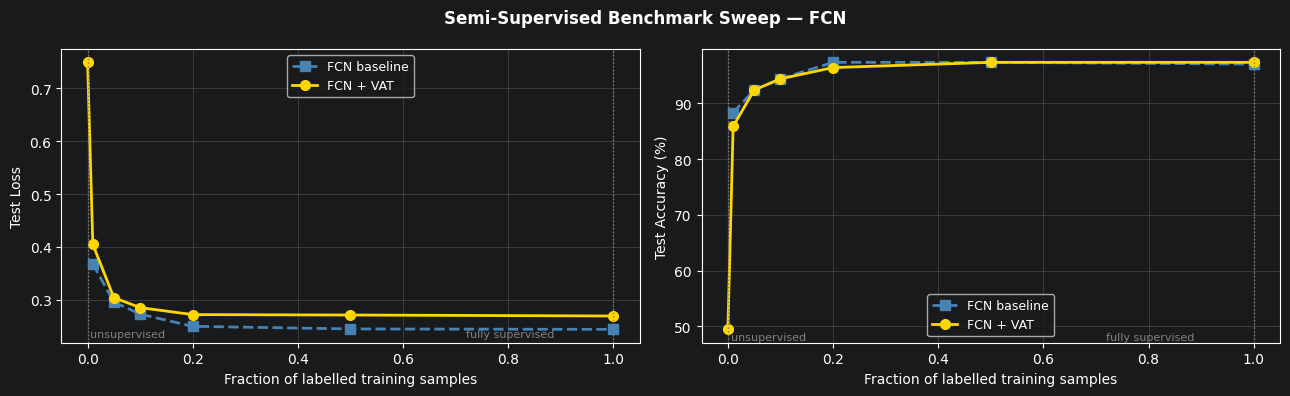

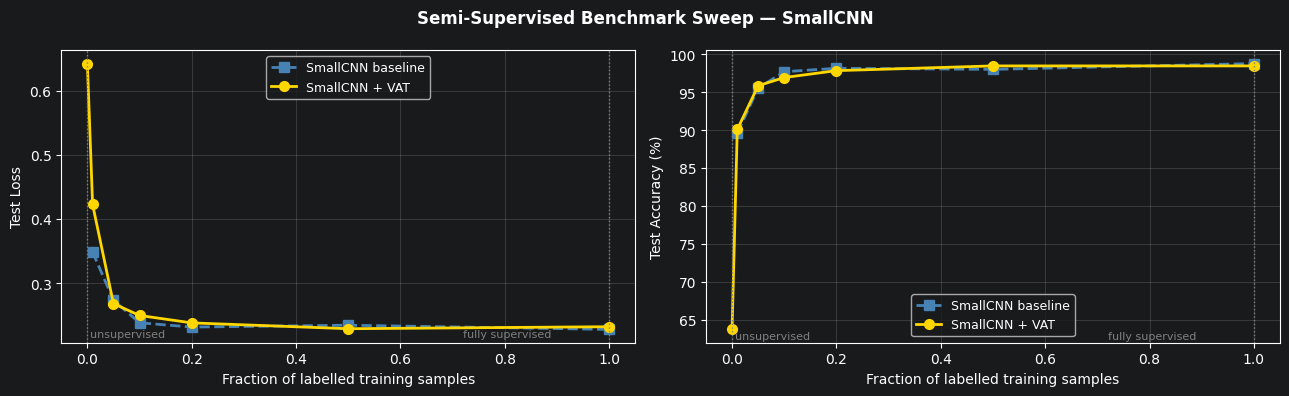

In [10]:
import matplotlib.pyplot as plt

# ── Summary table ─────────────────────────────────────────────────────
KEYS = ['FCN / vat', 'FCN / baseline', 'SmallCNN / vat', 'SmallCNN / baseline']

col_w = 14
header = f'  {"Labeled %":>18}' + ''.join(f'{k:>{col_w}}' for k in KEYS)
print(f'\n{"="*( 20 + col_w * len(KEYS))}')
print(header)
print(f'  {"-"*(18 + col_w * len(KEYS))}')
for frac, modes in sweep.items():
    label = 'unsupervised' if frac == 0.0 else ('fully supervised' if frac == 1.0 else f'{frac:.0%} labels')
    row = f'  {label:>18}'
    for k in KEYS:
        acc = f'{modes[k]["test_acc"]*100:.2f}%' if k in modes else 'n/a'
        row += f'{acc:>{col_w}}'
    print(row)
print(f'{"="*(20 + col_w * len(KEYS))}\n')


# ── Benchmark sweep plots ──────────────────────────────────────────────
def plot_sweep_metrics(pairs, sweep_data, fractions, title):
    """
    Generates a figure with two subplots (Test Loss and Test Accuracy)
    for a given set of model configurations over varying labeled fractions.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontweight='bold')

    for key, color, linestyle, label in pairs:
        valid_fracs = [f for f in fractions if key in sweep_data[f]]

        # Extracts metrics, defaulting to 0 for loss if unavailable in the dictionary
        accs = [sweep_data[f][key].get('test_acc', 0.0) * 100 for f in valid_fracs]
        losses = [sweep_data[f][key].get('test_loss', 0.0) for f in valid_fracs]

        ax1.plot(valid_fracs, losses, linestyle, color=color, label=label, linewidth=2, markersize=7)
        ax2.plot(valid_fracs, accs,   linestyle, color=color, label=label, linewidth=2, markersize=7)

    for ax, ylabel in [(ax1, 'Test Loss'), (ax2, 'Test Accuracy (%)')]:
        ax.set_xlabel('Fraction of labelled training samples')
        ax.set_ylabel(ylabel)

        # Adds visual markers for fully supervised and unsupervised bounds
        ax.axvline(0.0, color='grey', linestyle=':', linewidth=1)
        ax.axvline(1.0, color='grey', linestyle=':', linewidth=1)
        ybot = ax.get_ylim()[0]

        # Adjusts text placement dynamically based on the y-axis scale
        y_offset = 0.5 if 'Accuracy' in ylabel else (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.02
        ax.text(0.005, ybot + y_offset, 'unsupervised', fontsize=8, color='grey')
        ax.text(0.72,  ybot + y_offset, 'fully supervised', fontsize=8, color='grey')

        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# Plots FCN models (Baseline vs VAT)
plot_sweep_metrics(
    [
        ('FCN / baseline', 'steelblue', 's--', 'FCN baseline'),
        ('FCN / vat',      'gold',      'o-',  'FCN + VAT')
    ],
    sweep,
    FRACTIONS,
    'Semi-Supervised Benchmark Sweep — FCN'
)

# Plots SmallCNN models (Baseline vs VAT)
plot_sweep_metrics(
    [
        ('SmallCNN / baseline', 'steelblue', 's--', 'SmallCNN baseline'),
        ('SmallCNN / vat',      'gold',      'o-',  'SmallCNN + VAT')
    ],
    sweep,
    FRACTIONS,
    'Semi-Supervised Benchmark Sweep — SmallCNN'
)